In [ ]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
import pandas as pd
import scanpy as sc
import os
import matplotlib.pyplot as plt
import seaborn as sns
seed = 10
np.random.seed(seed)
sc.settings.verbosity = 3
import scrublet as scr
sc.settings.set_figure_params(dpi=300, facecolor='white')

## mapping to old dataset clustering

## project

In [ ]:
import scanpy as sc
import pandas as pd
sc.settings.verbosity = 1 
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(5, 5), facecolor="white")

In [ ]:
adata_ref = sc.read_h5ad("./sex_chimeric_only_Macro.h5ad")
ifnrko_file = './deconvolution_IFNRKO_10/inferreddata/merged_inferred_IFNRKO_data_labelled.h5ad'
cd45_1_file = './deconvolution_CD451_10/inferreddata/merged_inferred_CD45_1_data_labelled.h5ad'

adata_ifnrko = sc.read_h5ad(ifnrko_file)
adata_cd45_1 = sc.read_h5ad(cd45_1_file)
adata_exp_1 = sc.read_h5ad("./deconvolution_CD451_10/scRNA_CD45_1_norm_filtered.h5ad")
adata_exp_2 = sc.read_h5ad("./deconvolution_IFNRKO_10/scRNA_IFNRKO_norm_filtered.h5ad")

adata_exp = sc.concat([adata_exp_1, adata_exp_2], join="inner")

common_genes = list(set(adata_ifnrko.var_names) & set(adata_cd45_1.var_names) & set(adata_exp.var_names))
adata_ifnrko = adata_ifnrko[:, common_genes]
adata_cd45_1 = adata_cd45_1[:, common_genes]
adata_exp = adata_exp[:, common_genes]
adata = sc.concat(
    [adata_ifnrko, adata_cd45_1, adata_exp], 
    axis=0, 
    join="outer",
    label="batch", 
    keys=["IFNRKO", "CD45.1", "EXP"]
)

In [ ]:
adata_ref.X = adata_ref.raw[:, adata_ref.var_names].X
adata_ref.X = np.expm1(adata_ref.X)


In [9]:
adata_ref = adata_ref[adata_ref.obs['leiden_Macro'] != 'Macrophage C10'].copy()

In [11]:
adata_ref.obs['batch'] = 'old'
adata.obs['batch'] = 'new'
var_names = adata_ref.var_names.intersection(adata.var_names)
adata_ref = adata_ref[:, var_names]
adata = adata[:, var_names]

In [ ]:
sc.pp.pca(adata_ref)
sc.pp.neighbors(adata_ref, n_neighbors=10, n_pcs=40)
sc.pl.umap(adata_ref, color="leiden_Macro")

/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


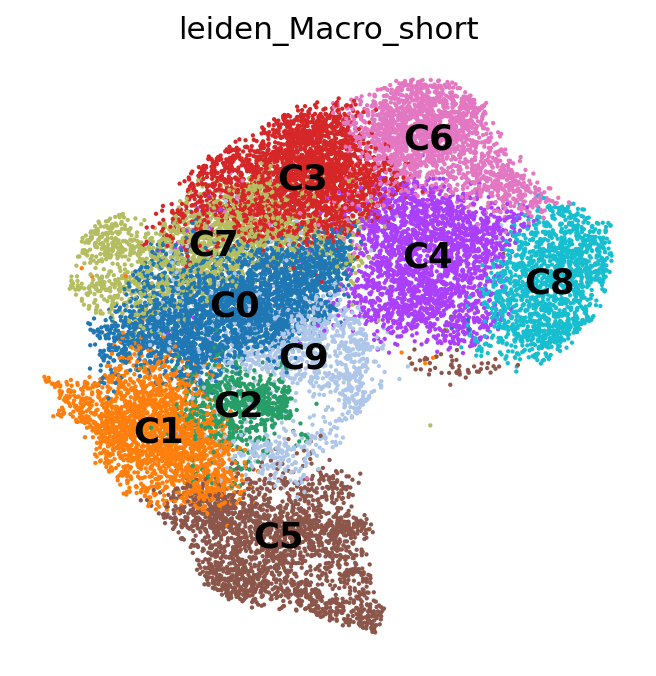

In [ ]:
adata_ref.obs["leiden_Macro_short"] = adata_ref.obs['leiden_Macro'].str.replace('Macrophage ', '')
sc.pl.umap(adata_ref, color=["leiden_Macro_short"],legend_loc="on data",legend_fontsize=16,s=15)

In [ ]:
sc.tl.ingest(adata, adata_ref, obs="leiden_Macro_short")

/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observat

In [ ]:
adata.uns["leiden_Macro_colors"] = adata_ref.uns["leiden_Macro_colors"]

/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


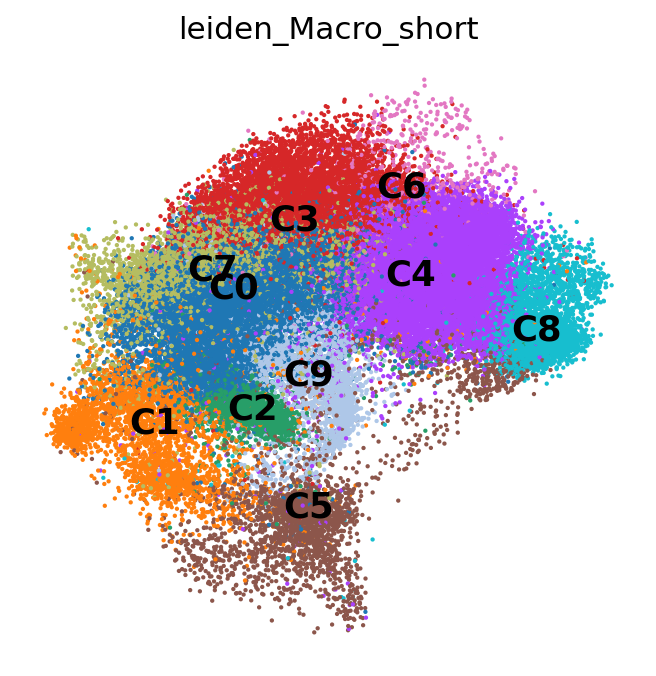

In [ ]:
sc.set_figure_params(figsize=(5, 5), frameon=False)
sc.pl.umap(adata, color=["leiden_Macro_short"],legend_loc="on data",legend_fontsize=16,s=15)

/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


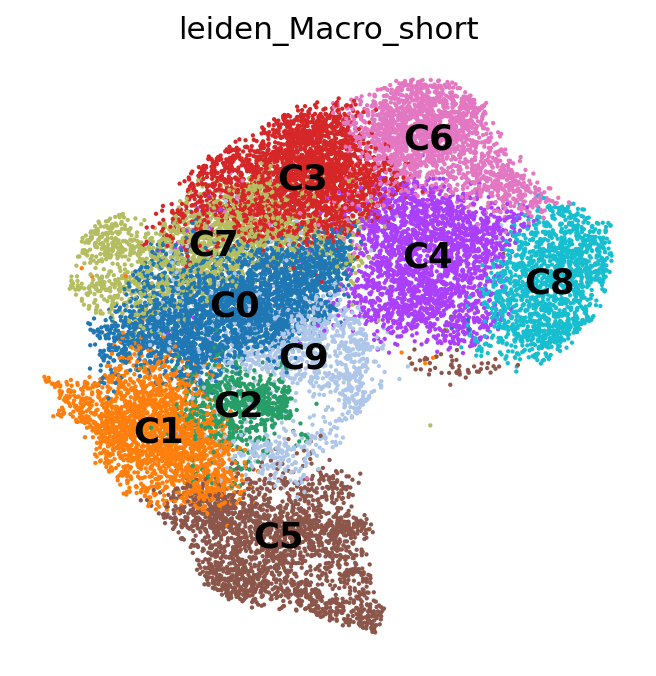

In [ ]:
sc.pl.umap(adata_ref, color=["leiden_Macro_short"],legend_loc="on data",legend_fontsize=16,s=15)

In [ ]:
import numpy as np
source_str = adata.obs["source_file"].astype(str)
groups_str = adata.obs["sample_ids"].astype(str)
source_str = source_str.replace("nan", np.nan)
filled = source_str.fillna(groups_str)
adata.obs["source_file"] = pd.Categorical(filled)

In [ ]:
adata.obs['groups'] = adata.obs['source_file'].map({'im3_to_im1':'IFNR-/-', 'im3_to_im2':'IFNR-/-', 'im3_to_im4':'IFNR-/-',
       'im3_to_im5':'IFNR-/-', 'im3_to_im6':'IFNR-/-', 'im3_to_im7':'IFNR-/-',
        'wm2_to_wm1': 'CD45.1', 'wm2_to_wm3': 'CD45.1', 'wm2_to_wm4': 'CD45.1', 'wm2_to_wm5': 'CD45.1',
        'im3':'IFNR-/-','wm2': 'CD45.1'})


/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


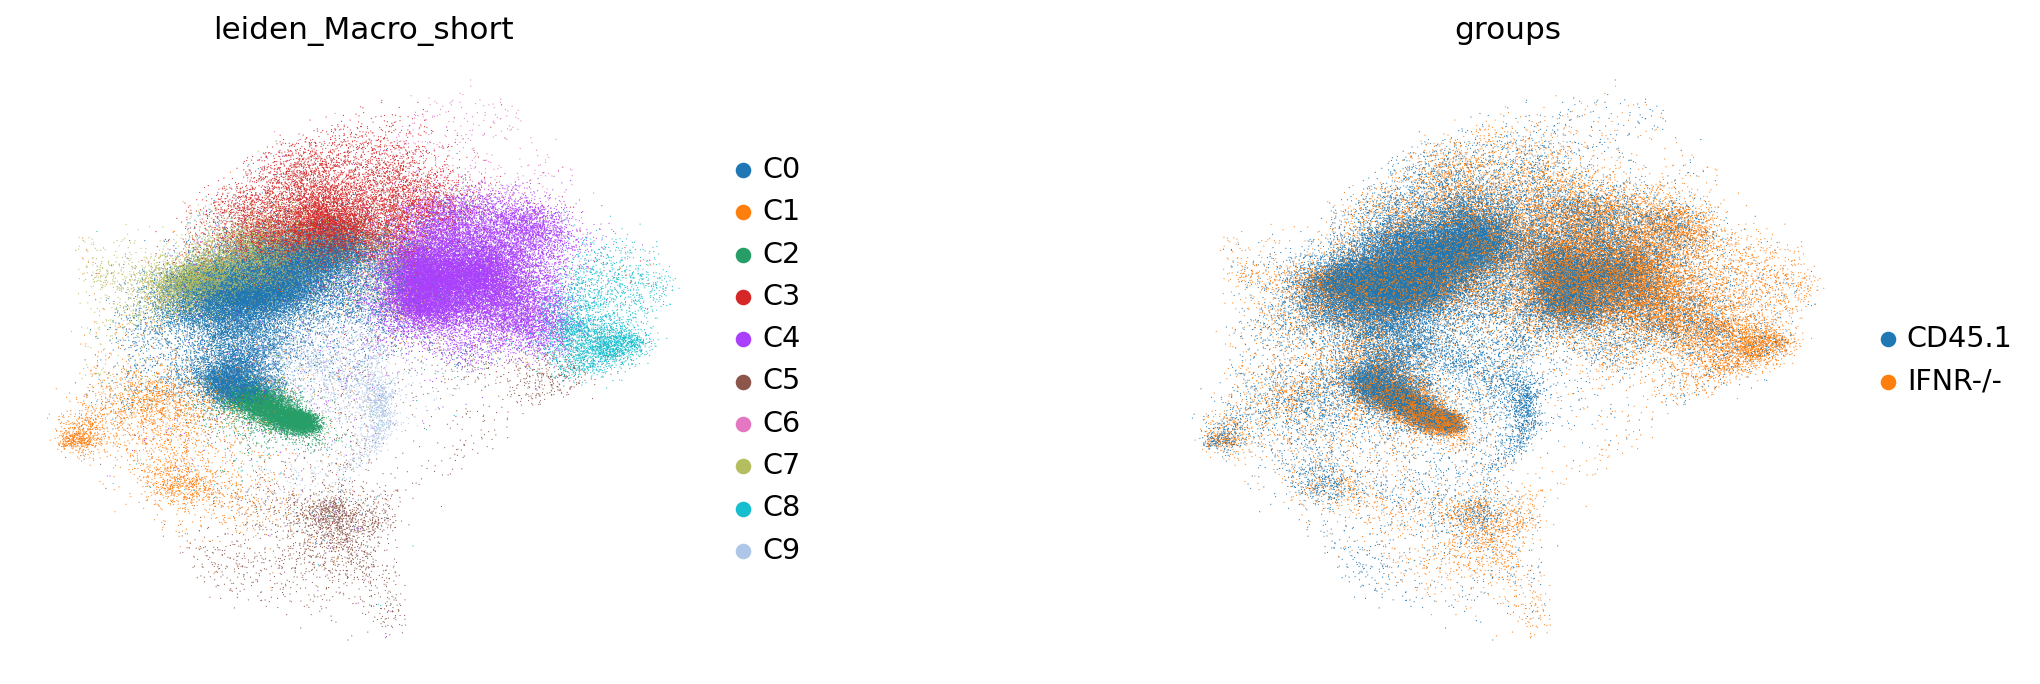

In [ ]:
sc.pl.umap(adata, color=["leiden_Macro_short", "groups"], wspace=0.5)

In [ ]:
adata.write('./merged_ingest.h5ad')

In [ ]:
ifnrko_mlp_path = './deconvolution_IFNRKO_10/inferreddata/merged_inferred_IFNRKO_data_labelled_ingest.h5ad'
ifnrko_mlp = sc.read_h5ad(ifnrko_mlp_path)

cd45_1_mlp_path = './deconvolution_CD451_10/inferreddata/merged_inferred_CD45_1_data_labelled_ingest.h5ad'
cd45_1_mlp = sc.read_h5ad(cd45_1_mlp_path)
adata_combined = sc.concat([ifnrko_mlp, cd45_1_mlp]    
                           ,axis=0, 
    join="outer",
    label="batch", 
    keys=["IFNRKO", "CD45.1"])

/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/mnt/data/jiahui/anaconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
import numpy as np
celltypes = adata_combined.obs['celltypes'].to_list()
padding_len = adata.n_obs - len(celltypes)

if padding_len > 0:
    celltypes += [np.nan] * padding_len

adata.obs['inferred_celltypes'] = celltypes
adata.obs['inferred_celltypes'] = adata.obs['inferred_celltypes'].fillna(adata.obs['leiden_Macro_short'])